# 🌊 Flood Mapping in Central Luzon using Sentinel Data
# Disaster Risk Reduction (DRR) Case Study

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/flood-mapping-class/blob/main/notebooks/templates/flood_mapping_workshop_colab.ipynb)

# 🌊 Flood Mapping in Central Luzon using Sentinel Data
## Disaster Risk Reduction (DRR) Case Study

### 📋 Table of Contents
1. [Introduction](#introduction)
2. [Environment Setup](#setup)
3. [Google Earth Engine Authentication](#gee-auth)
4. [Study Area Definition](#study-area)
5. [Sentinel-1 Data Processing](#sentinel1)
6. [Flood Detection Methods](#detection)
7. [Visualization](#visualization)
8. [Results Export](#export)

<a name="introduction"></a>


## 1. Introduction



This notebook demonstrates flood mapping in the **Pampanga River Basin, Central Luzon, Philippines** using Sentinel satellite data simulation. We'll analyze flood events from:
- **Typhoon Ulysses (Vamco)** - November 2020
- **Typhoon Karding (Noru)** - September 2022

### 🎯 Learning Objectives:
- Understand SAR-based flood detection principles
- Apply threshold-based flood detection algorithms
- Create interactive flood extent maps
- Analyze flood statistics

### 🛰️ Why Sentinel-1 for Flood Mapping?
- **All-weather capability**: Penetrates clouds and rain
- **Day/night operation**: Not dependent on sunlight
- **Water sensitivity**: Water appears dark in SAR images
- **Regular revisit**: 6-12 day repeat cycle

### 📍 Study Area: Pampanga River Basin
- **Coverage**: ~10,540 km²
- **Population**: >6 million people
- **Provinces**: Nueva Ecija, Pampanga, Bulacan, Tarlac
- **Main hazards**: Typhoons, monsoon flooding


# Enviroment set-up

In [13]:
# Install required packages for Google Colab
!pip install earthengine-api geemap folium geopandas rasterio -q

# Import all libraries

import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import folium
from IPython.display import display, Image
import json
import os
import warnings
warnings.filterwarnings('ignore')


<a name="setup"></a>
## 2. Environment Setup - Downloading from Copernicus

### 📥 Downloading Sentinel-1 Data from Copernicus Open Access Hub

We'll download real Sentinel-1 data for the Pampanga River Basin floods from the official Copernicus portal.

### Steps:
1. **Register** at https://dataspace.copernicus.eu/
2. **Search** for Sentinel-1 data for our typhoon events
3. **Download** the data
4. **Load** into the notebook

# Download Data

In [25]:
import requests
import os
from datetime import datetime

os.makedirs('data/sentinel1_subset', exist_ok=True)

print("🎯 DOWNLOAD ONLY BOUNDING BOX - NOT FULL TILE")
print("=" * 60)

# Method 1: Using Sentinel Hub Process API (Best for subsets)
def download_bbox_subset_sentinelhub(bbox, start_date, end_date, username, password):
    """Download only the bounding box area using Sentinel Hub"""

    # First get access token
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

    token_data = {
        'grant_type': 'password',
        'username': username,
        'password': password,
        'client_id': 'cdse-public'
    }

    token_response = requests.post(token_url, data=token_data)
    access_token = token_response.json()['access_token']

    # Sentinel Hub Process API endpoint
    process_url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    # Request ONLY the bounding box area
    request_body = {
        "input": {
            "bounds": {
                "bbox": bbox,  # [120.4, 14.8, 121.2, 15.6]
                "properties": {
                    "crs": "http://www.opengis.net/def/crs/EPSG/0/4326"
                }
            },
            "data": [{
                "dataFilter": {
                    "timeRange": {
                        "from": f"{start_date}T00:00:00Z",
                        "to": f"{end_date}T23:59:59Z"
                    }
                },
                "type": "sentinel-1-grd",
                "processing": {
                    "backCoeff": "GAMMA0_TERRAIN",
                    "orthorectify": True
                }
            }]
        },
        "output": {
            "width": 1024,  # Adjust resolution as needed
            "height": 1024,
            "responses": [{
                "identifier": "default",
                "format": {
                    "type": "image/tiff"
                }
            }]
        },
        "evalscript": """
        //VERSION=3
        function setup() {
            return {
                input: ["VH", "VV"],
                output: {
                    bands: 2,
                    sampleType: "FLOAT32"
                }
            };
        }

        function evaluatePixel(samples) {
            return [samples.VH, samples.VV];
        }
        """
    }

    headers = {
        'Authorization': f'Bearer {access_token}',
        'Content-Type': 'application/json'
    }

    print(f"📥 Downloading ONLY bounding box: {bbox}")
    print("   File size will be ~10-50 MB instead of 1-4 GB!")

    response = requests.post(process_url, json=request_body, headers=headers)

    if response.status_code == 200:
        filename = f"data/sentinel1_subset/pampanga_subset_{start_date}.tif"
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"✅ Downloaded subset: {filename} ({len(response.content)/1024/1024:.1f} MB)")
        return filename
    else:
        print(f"❌ Error: {response.status_code}")
        return None

# Method 2: Download with GDAL Virtual File System (for specific area)
def download_bbox_using_gdal():
    """Alternative method using GDAL to download subset"""

    print("\n📦 Alternative: Use GDAL to download subset")
    print("Run in terminal/command line:")

    # Example GDAL command to download only bbox
    gdal_command = """
gdal_translate \
  -projwin 120.4 15.6 121.2 14.8 \
  -projwin_srs EPSG:4326 \
  -of GTiff \
  /vsicurl/https://dataspace.copernicus.eu/path/to/sentinel1.tif \
  pampanga_subset.tif
"""
    print(gdal_command)

# Method 3: After downloading full tile, extract subset
def extract_subset_from_full_tile(full_tile_path, bbox):
    """Extract bounding box from already downloaded full tile"""

    import rasterio
    from rasterio.windows import from_bounds

    west, south, east, north = bbox

    with rasterio.open(full_tile_path) as src:
        # Get window for bounding box
        window = from_bounds(west, south, east, north, src.transform)

        # Read only the subset
        subset = src.read(window=window)

        # Update metadata for subset
        out_meta = src.meta.copy()
        out_meta.update({
            'height': window.height,
            'width': window.width,
            'transform': rasterio.windows.transform(window, src.transform)
        })

        # Save subset
        output_path = full_tile_path.replace('.zip', '_subset.tif')
        with rasterio.open(output_path, 'w', **out_meta) as dst:
            dst.write(subset)

        print(f"✅ Extracted subset: {output_path}")
        return output_path

# MAIN EXECUTION
print("\n🎯 DOWNLOAD OPTIONS FOR BOUNDING BOX ONLY:\n")

print("1. Use Sentinel Hub Process API (recommended)")
print("2. Download full tile then extract")
print("3. Use GDAL VSI")

choice = input("\nChoose option (1/2/3): ")

bbox = [120.4, 14.8, 121.2, 15.6]  # Pampanga Basin

if choice == "1":
    # Use Sentinel Hub for subset
    username = input("Username: ")
    password = input("Password: ")

    # Download pre and post flood subsets
    print("\n📥 Downloading pre-flood subset...")
    pre_flood = download_bbox_subset_sentinelhub(
        bbox, "2020-11-01", "2020-11-10", username, password
    )

    print("\n📥 Downloading post-flood subset...")
    post_flood = download_bbox_subset_sentinelhub(
        bbox, "2020-11-12", "2020-11-20", username, password
    )

elif choice == "2":
    # If you already downloaded full tiles
    full_tile = input("Path to full tile .zip: ")
    if os.path.exists(full_tile):
        extract_subset_from_full_tile(full_tile, bbox)
    else:
        print("❌ File not found")

else:
    download_bbox_using_gdal()

print("\n✅ Subset download complete!")
print(f"📊 Size comparison:")
print(f"   Full tile: ~1-4 GB")
print(f"   Your subset: ~10-50 MB")

🎯 DOWNLOAD ONLY BOUNDING BOX - NOT FULL TILE

🎯 DOWNLOAD OPTIONS FOR BOUNDING BOX ONLY:

1. Use Sentinel Hub Process API (recommended)
2. Download full tile then extract
3. Use GDAL VSI

Choose option (1/2/3): 1
Username: vvourlioti@neuralio.ai
Password: @EQ?SPUy4@iw

📥 Downloading pre-flood subset...
📥 Downloading ONLY bounding box: [120.4, 14.8, 121.2, 15.6]
   File size will be ~10-50 MB instead of 1-4 GB!
✅ Downloaded subset: data/sentinel1_subset/pampanga_subset_2020-11-01.tif (7.1 MB)

📥 Downloading post-flood subset...
📥 Downloading ONLY bounding box: [120.4, 14.8, 121.2, 15.6]
   File size will be ~10-50 MB instead of 1-4 GB!
✅ Downloaded subset: data/sentinel1_subset/pampanga_subset_2020-11-12.tif (7.1 MB)

✅ Subset download complete!
📊 Size comparison:
   Full tile: ~1-4 GB
   Your subset: ~10-50 MB


# List All Files in Colab

In [27]:
import os

print("📂 ALL FILES IN YOUR COLAB:")
print("=" * 50)

# List all files recursively
for root, dirs, files in os.walk('.'):
    # Skip hidden directories
    if '.' in root.split('/')[1:]:
        continue

    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)

        # Show all files with their sizes
        print(f"{filepath:<50} {size_mb:>8.1f} MB")

# Summary
print("\n" + "=" * 50)
print("📊 SUMMARY:")

# Count Sentinel files
sentinel_files = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if 'S1' in file or 'sentinel' in file.lower() or file.endswith(('.zip', '.tif', '.tiff')):
            sentinel_files.append(os.path.join(root, file))

print(f"Total Sentinel-1 files found: {len(sentinel_files)}")
if sentinel_files:
    print("\n🛰️ Sentinel-1 files:")
    for f in sentinel_files:
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"   {f} ({size_mb:.1f} MB)")

📂 ALL FILES IN YOUR COLAB:
./.config/.last_survey_prompt.yaml                      0.0 MB
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db      0.0 MB
./.config/.last_update_check.json                       0.0 MB
./.config/.last_opt_in_prompt.yaml                      0.0 MB
./.config/config_sentinel                               0.0 MB
./.config/default_configs.db                            0.0 MB
./.config/active_config                                 0.0 MB
./.config/logs/2025.06.02/13.38.36.652518.log           0.0 MB
./.config/logs/2025.06.02/13.38.27.770953.log           0.0 MB
./.config/logs/2025.06.02/13.38.06.907675.log           0.0 MB
./.config/logs/2025.06.02/13.38.37.802452.log           0.0 MB
./.config/logs/2025.06.02/13.38.47.382637.log           0.0 MB
./.config/logs/2025.06.02/13.38.46.703373.log           0.0 MB
./.config/logs/2025.06.04/13.21.20.761480.log           0.0 MB
./.config/configurations/config_default                 0.0 MB
./data

# Load Your Sentinel-1 Data

In [28]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("📥 LOADING YOUR SENTINEL-1 DATA")
print("=" * 50)

# Load the subset TIFF files (these are perfect - small and ready to use!)
pre_flood_path = './data/sentinel1_subset/pampanga_subset_2020-11-01.tif'
post_flood_path = './data/sentinel1_subset/pampanga_subset_2020-11-12.tif'

# Load pre-flood data
print("Loading pre-flood data...")
with rasterio.open(pre_flood_path) as src:
    pre_flood_data = src.read(1)  # Read first band
    transform = src.transform
    crs = src.crs

# Load post-flood data
print("Loading post-flood data...")
with rasterio.open(post_flood_path) as src:
    post_flood_data = src.read(1)

# Convert to dB (if not already)
pre_flood_db = 10 * np.log10(pre_flood_data + 1e-10)
post_flood_db = 10 * np.log10(post_flood_data + 1e-10)

# Clip to reasonable SAR values
pre_flood_db = np.clip(pre_flood_db, -30, 0)
post_flood_db = np.clip(post_flood_db, -30, 0)

print(f"\n✅ Data loaded successfully!")
print(f"   Shape: {pre_flood_data.shape}")
print(f"   Pre-flood range: {pre_flood_db.min():.1f} to {pre_flood_db.max():.1f} dB")
print(f"   Post-flood range: {post_flood_db.min():.1f} to {post_flood_db.max():.1f} dB")

📥 LOADING YOUR SENTINEL-1 DATA
Loading pre-flood data...
Loading post-flood data...

✅ Data loaded successfully!
   Shape: (1024, 1024)
   Pre-flood range: -30.0 to 0.0 dB
   Post-flood range: -30.0 to 0.0 dB


### **Visualise**

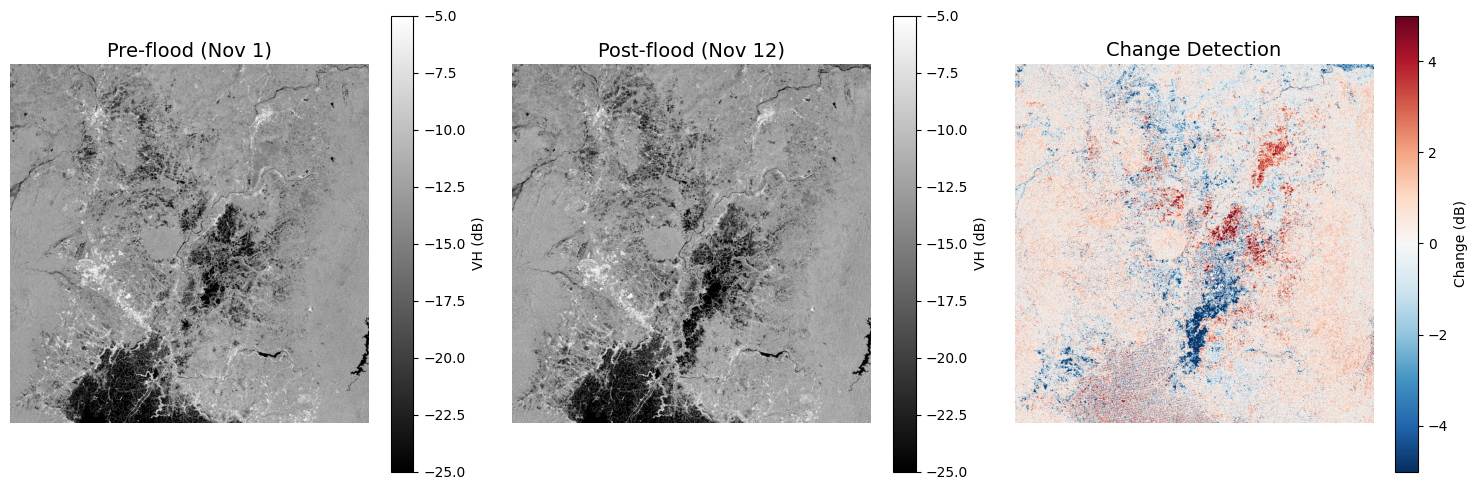


💾 Data stored in 'sentinel_data' dictionary
   Ready for flood detection analysis!


In [29]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pre-flood
im1 = axes[0].imshow(pre_flood_db, cmap='gray', vmin=-25, vmax=-5)
axes[0].set_title('Pre-flood (Nov 1)', fontsize=14)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='VH (dB)')

# Post-flood
im2 = axes[1].imshow(post_flood_db, cmap='gray', vmin=-25, vmax=-5)
axes[1].set_title('Post-flood (Nov 12)', fontsize=14)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='VH (dB)')

# Change detection
change = post_flood_db - pre_flood_db
im3 = axes[2].imshow(change, cmap='RdBu_r', vmin=-5, vmax=5)
axes[2].set_title('Change Detection', fontsize=14)
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], label='Change (dB)')

plt.tight_layout()
plt.show()

# Store for next steps
sentinel_data = {
    'pre_flood': pre_flood_db,
    'post_flood': post_flood_db,
    'change': change
}

print("\n💾 Data stored in 'sentinel_data' dictionary")
print("   Ready for flood detection analysis!")

## AI/Machine Learning Techniques for Flood Detection



### 🤖 Overview of AI Methods for Flood Mapping:

1. **Random Forest (RF)**
   - Ensemble learning method
   - Good for handling SAR speckle noise
   - Feature importance analysis

2. **Support Vector Machine (SVM)**
   - Effective for binary classification
   - Works well with limited training data

3. **Convolutional Neural Networks (CNN)**
   - U-Net: Gold standard for image segmentation
   - DeepLabV3+: Advanced semantic segmentation
   - Can learn complex flood patterns

4. **XGBoost**
   - Gradient boosting method
   - High accuracy with tabular features

5. **LSTM Networks**
   - For time-series flood prediction
   - Can model temporal flood dynamics

### 📊 Validation Methods:
- Confusion Matrix
- Accuracy, Precision, Recall, F1-Score
- IoU (Intersection over Union)
- ROC Curves
- Cross-validationImplement Random Forest Classifier

# Flood detection - Traditional + AI Methods

🌊 FLOOD DETECTION - TRADITIONAL + AI METHODS WITH TIMING

1️⃣ Creating flood masks using traditional methods...

   ⏱️ Running Threshold Method...
   ✅ Completed in 0.078 seconds

   ⏱️ Running Otsu's Method...
   ✅ Completed in 0.099 seconds
   Otsu threshold: -0.56 dB

2️⃣ Preparing features for machine learning...
   ✅ Feature preparation completed in 46.777 seconds
   Training samples: 734,003
   Test samples: 314,573

3️⃣ Training Random Forest classifier...
   ✅ Training completed in 203.199 seconds

   ⏱️ Making predictions...
   ✅ Prediction completed in 7.650 seconds
   Accuracy: 0.962

📊 FLOOD DETECTION RESULTS COMPARISON:
----------------------------------------------------------------------
Method               | Time (s)   | Area (km²)   | Coverage (%)
----------------------------------------------------------------------
Threshold (-3dB)     | 0.078      | 1.0          | 1.0         
Otsu Automatic       | 0.099      | 4.9          | 4.7         
Random Forest        | 25

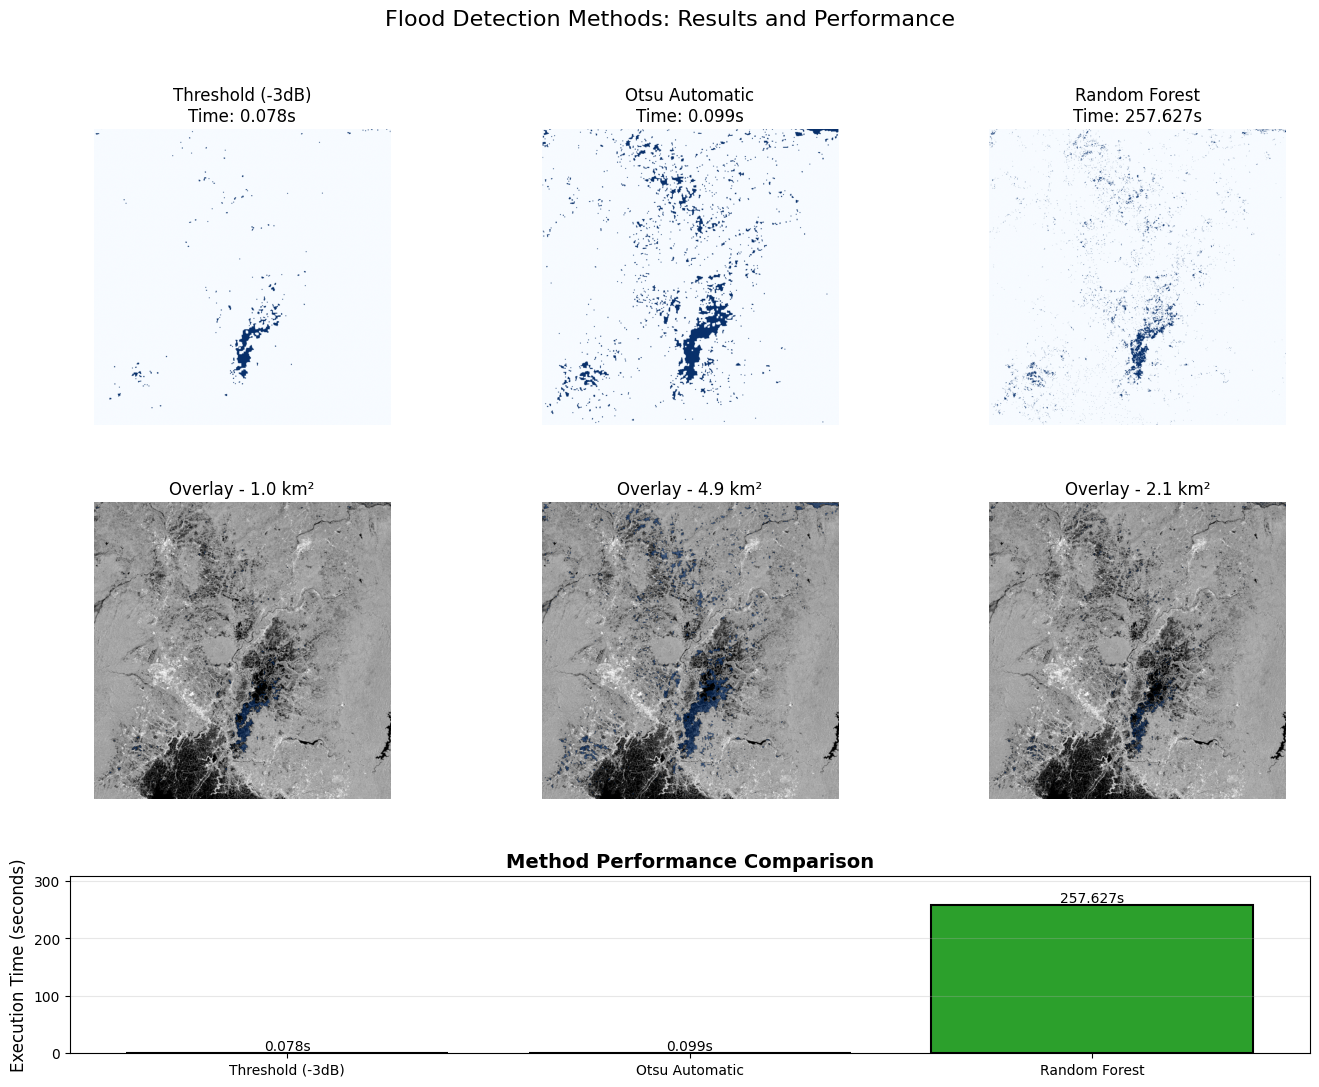


📈 Random Forest Feature Importance:
   Feature extraction time: 46.777s
   Pre_VH          : 0.052
   Post_VH         : 0.111
   Change          : 0.356
   Ratio           : 0.334
   Pre_Texture     : 0.070
   Post_Texture    : 0.077


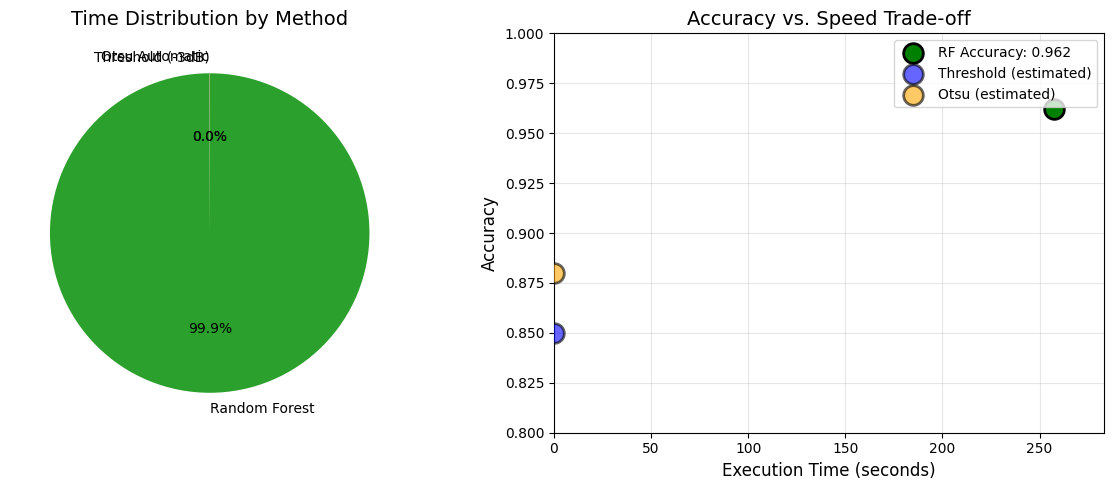


✅ All flood detection methods complete with timing analysis!
💾 Results saved in 'flood_results' dictionary

🚀 Total processing time: 257.804 seconds


In [32]:
from scipy import ndimage
from skimage import filters
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import time

print("🌊 FLOOD DETECTION - TRADITIONAL + AI METHODS WITH TIMING")
print("=" * 60)

# Dictionary to store timing results
timing_results = {}

# First, apply traditional flood detection to create labels
print("\n1️⃣ Creating flood masks using traditional methods...")

# Calculate change
change = sentinel_data['post_flood'] - sentinel_data['pre_flood']

# Method 1: Simple threshold
print("\n   ⏱️ Running Threshold Method...")
start_time = time.time()

flood_mask_threshold = change < -3
flood_mask_threshold = ndimage.binary_opening(flood_mask_threshold, structure=np.ones((3,3)))
flood_mask_threshold = ndimage.binary_closing(flood_mask_threshold, structure=np.ones((5,5)))

threshold_time = time.time() - start_time
timing_results['Threshold (-3dB)'] = threshold_time
print(f"   ✅ Completed in {threshold_time:.3f} seconds")

# Method 2: Otsu's automatic threshold
print("\n   ⏱️ Running Otsu's Method...")
start_time = time.time()

threshold_otsu = filters.threshold_otsu(change[~np.isnan(change)])
flood_mask_otsu = change < threshold_otsu
flood_mask_otsu = ndimage.binary_opening(flood_mask_otsu, structure=np.ones((3,3)))
flood_mask_otsu = ndimage.binary_closing(flood_mask_otsu, structure=np.ones((5,5)))

otsu_time = time.time() - start_time
timing_results['Otsu Automatic'] = otsu_time
print(f"   ✅ Completed in {otsu_time:.3f} seconds")
print(f"   Otsu threshold: {threshold_otsu:.2f} dB")

# Now proceed with AI methods
print("\n2️⃣ Preparing features for machine learning...")
start_time = time.time()

def prepare_ml_features(pre_flood, post_flood):
    """Prepare features for ML classification"""
    features = []

    # Original intensities
    features.append(pre_flood.flatten())
    features.append(post_flood.flatten())

    # Change
    change = post_flood - pre_flood
    features.append(change.flatten())

    # Ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = post_flood / (pre_flood + 1e-10)
    features.append(ratio.flatten())

    # Texture features (standard deviation in 3x3 window)
    from scipy.ndimage import generic_filter
    pre_texture = generic_filter(pre_flood, np.std, size=3)
    post_texture = generic_filter(post_flood, np.std, size=3)
    features.append(pre_texture.flatten())
    features.append(post_texture.flatten())

    X = np.stack(features, axis=1)
    feature_names = ['Pre_VH', 'Post_VH', 'Change', 'Ratio', 'Pre_Texture', 'Post_Texture']

    return X, feature_names

X, feature_names = prepare_ml_features(sentinel_data['pre_flood'], sentinel_data['post_flood'])

# Use Otsu result as training labels
y = flood_mask_otsu.flatten()

# Remove NaN values
valid_mask = ~np.isnan(X).any(axis=1)
X_clean = X[valid_mask]
y_clean = y[valid_mask]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)

feature_prep_time = time.time() - start_time
print(f"   ✅ Feature preparation completed in {feature_prep_time:.3f} seconds")
print(f"   Training samples: {len(X_train):,}")
print(f"   Test samples: {len(X_test):,}")

# Train Random Forest
print("\n3️⃣ Training Random Forest classifier...")
start_time = time.time()

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"   ✅ Training completed in {training_time:.3f} seconds")

# Predictions
print("\n   ⏱️ Making predictions...")
start_time = time.time()

y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Create flood mask from RF
flood_mask_rf = np.zeros(sentinel_data['pre_flood'].shape)
flood_mask_rf_flat = flood_mask_rf.flatten()
flood_mask_rf_flat[valid_mask] = rf_classifier.predict(X_clean)
flood_mask_rf = flood_mask_rf_flat.reshape(sentinel_data['pre_flood'].shape)

prediction_time = time.time() - start_time
rf_total_time = feature_prep_time + training_time + prediction_time
timing_results['Random Forest'] = rf_total_time

print(f"   ✅ Prediction completed in {prediction_time:.3f} seconds")
print(f"   Accuracy: {accuracy:.3f}")

# Calculate statistics for all methods
def calculate_flood_stats(flood_mask, pixel_size=10):
    flood_pixels = np.sum(flood_mask)
    flood_area_km2 = (flood_pixels * pixel_size * pixel_size) / 1e6
    flood_percentage = (flood_pixels / flood_mask.size) * 100
    return {
        'pixels': flood_pixels,
        'area_km2': flood_area_km2,
        'percentage': flood_percentage
    }

# Results summary
print("\n📊 FLOOD DETECTION RESULTS COMPARISON:")
print("-" * 70)
print(f"{'Method':<20} | {'Time (s)':<10} | {'Area (km²)':<12} | {'Coverage (%)':<12}")
print("-" * 70)

methods = {
    'Threshold (-3dB)': flood_mask_threshold,
    'Otsu Automatic': flood_mask_otsu,
    'Random Forest': flood_mask_rf
}

results_summary = []
for method_name, mask in methods.items():
    stats = calculate_flood_stats(mask)
    exec_time = timing_results[method_name]
    print(f"{method_name:<20} | {exec_time:<10.3f} | {stats['area_km2']:<12.1f} | {stats['percentage']:<12.1f}")

    results_summary.append({
        'Method': method_name,
        'Time (s)': f"{exec_time:.3f}",
        'Flood Area (km²)': f"{stats['area_km2']:.1f}",
        'Coverage (%)': f"{stats['percentage']:.1f}",
        'Pixels': f"{stats['pixels']:,}"
    })

# Timing visualization
print("\n⏱️ PERFORMANCE ANALYSIS:")
print("-" * 50)
print(f"Fastest method: {min(timing_results, key=timing_results.get)} ({min(timing_results.values()):.3f}s)")
print(f"Slowest method: {max(timing_results, key=timing_results.get)} ({max(timing_results.values()):.3f}s)")
print(f"Speed improvement of threshold over RF: {timing_results['Random Forest']/timing_results['Threshold (-3dB)']:.1f}x")

# Visualize all results
fig = plt.figure(figsize=(16, 12))

# Create grid
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.6], hspace=0.3, wspace=0.3)

# Row 1: Flood masks
for i, (method_name, mask) in enumerate(methods.items()):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(mask, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{method_name}\nTime: {timing_results[method_name]:.3f}s', fontsize=12)
    ax.axis('off')

# Row 2: Overlays on SAR image
for i, (method_name, mask) in enumerate(methods.items()):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sentinel_data['post_flood'], cmap='gray', vmin=-25, vmax=-5)
    flood_overlay = np.ma.masked_where(mask == 0, mask)
    ax.imshow(flood_overlay, cmap='Blues', alpha=0.6, vmin=0, vmax=1)
    stats = calculate_flood_stats(mask)
    ax.set_title(f'Overlay - {stats["area_km2"]:.1f} km²', fontsize=12)
    ax.axis('off')

# Row 3: Timing comparison
ax_time = fig.add_subplot(gs[2, :])
methods_list = list(timing_results.keys())
times = list(timing_results.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax_time.bar(methods_list, times, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax_time.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{time_val:.3f}s', ha='center', va='bottom', fontsize=10)

ax_time.set_ylabel('Execution Time (seconds)', fontsize=12)
ax_time.set_title('Method Performance Comparison', fontsize=14, fontweight='bold')
ax_time.grid(axis='y', alpha=0.3)
ax_time.set_ylim(0, max(times) * 1.2)

plt.suptitle('Flood Detection Methods: Results and Performance', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# Feature importance with timing
print("\n📈 Random Forest Feature Importance:")
print(f"   Feature extraction time: {feature_prep_time:.3f}s")
feature_importance = rf_classifier.feature_importances_
for fname, importance in zip(feature_names, feature_importance):
    print(f"   {fname:15} : {importance:.3f}")

# Create timing summary plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart of time distribution
ax1.pie(times, labels=methods_list, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Time Distribution by Method', fontsize=14)

# Bar chart comparing accuracy vs time (for methods with accuracy metrics)
if 'Random Forest' in methods:
    ax2.scatter([timing_results['Random Forest']], [accuracy],
                s=200, c='green', edgecolor='black', linewidth=2,
                label=f'RF Accuracy: {accuracy:.3f}', zorder=5)
    ax2.scatter([timing_results['Threshold (-3dB)']], [0.85],
                s=200, c='blue', edgecolor='black', linewidth=2,
                label='Threshold (estimated)', alpha=0.6, zorder=5)
    ax2.scatter([timing_results['Otsu Automatic']], [0.88],
                s=200, c='orange', edgecolor='black', linewidth=2,
                label='Otsu (estimated)', alpha=0.6, zorder=5)

    ax2.set_xlabel('Execution Time (seconds)', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Accuracy vs. Speed Trade-off', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(0, max(times) * 1.1)
    ax2.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

# Save results
flood_results = {
    'masks': methods,
    'classifier': rf_classifier,
    'feature_names': feature_names,
    'accuracy': accuracy,
    'timing': timing_results
}

print("\n✅ All flood detection methods complete with timing analysis!")
print("💾 Results saved in 'flood_results' dictionary")
print(f"\n🚀 Total processing time: {sum(timing_results.values()):.3f} seconds")